[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BrainardLab/PythonTeachingCode/blob/main/notebooks/HeightDistribution.ipynb)

_Run this notebook in the browser — no install needed._

# Height distribution

Standing height of adult women from a deliberately **homogeneous**
sample (one sex, one age band, one self-reported race/ethnicity group).
With the sources of variation narrowed like this, height is about as
close to normal as real data gets -- the opposite of the stock-change
notebook.

Data: [NHANES](https://wwwn.cdc.gov/nchs/nhanes/), the CDC's National
Health and Nutrition Examination Survey. We pool the 2015-2016 and
2017-2018 cycles. Files are read straight from the CDC as SAS `.xpt`.

In [1]:
# --- Make dist_tools.py importable ---------------------------------------
# Locally it sits next to this notebook. On Colab we grab it from GitHub.
import os, urllib.request
if not os.path.exists("dist_tools.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/BrainardLab/PythonTeachingCode"
        "/main/notebooks/dist_tools.py",
        "dist_tools.py",
    )

# Optional: pick up edits to dist_tools.py without restarting the kernel.
# Skipped silently where the autoreload extension is unavailable (e.g. the
# Python 3.13 build currently on Google Colab).
try:
    _ip = get_ipython()
    _ip.run_line_magic("load_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")
except Exception:
    pass

import numpy as np
import pandas as pd
import dist_tools as dt

In [2]:
import io, urllib.request

def _xpt(url):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    return pd.read_sas(io.BytesIO(urllib.request.urlopen(req, timeout=90).read()),
                       format="xport")

frames = []
for year, suffix in [("2015", "I"), ("2017", "J")]:
    base = f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{year}/DataFiles/"
    demo = _xpt(base + f"DEMO_{suffix}.xpt")     # demographics
    bmx = _xpt(base + f"BMX_{suffix}.xpt")       # body measures
    frames.append(demo.merge(bmx[["SEQN", "BMXHT"]], on="SEQN"))

people = pd.concat(frames, ignore_index=True)

# RIAGENDR: 1 male, 2 female     RIDRETH3 == 3: non-Hispanic white
# RIDAGEYR: age in years         BMXHT: standing height in cm
homogeneous = people[
    (people.RIAGENDR == 2)
    & (people.RIDAGEYR.between(20, 59))
    & (people.RIDRETH3 == 3)
].dropna(subset=["BMXHT"])

height_cm = homogeneous["BMXHT"].reset_index(drop=True)

height = dt.Distribution(
    values=height_cm,
    quantity="Adult height",
    unit="cm",
    noun="women",
    source="NHANES 2015-2016 + 2017-2018 (CDC)",
    note="non-Hispanic white women, ages 20-59",
    bin_width=1.0,
)

Source:  NHANES 2015-2016 + 2017-2018 (CDC)
Sample:  non-Hispanic white women, ages 20-59
Women included:  1,054
Range:   143.7 to 189.3 cm
Mean:    163.6 cm
Std dev (1 sigma):  6.413 cm

          window | normal predicts |     actual women
-----------------------------------------------------
  beyond 1 sigma  |          334.45 |              333
  beyond 2 sigma  |           47.96 |               48
  beyond 3 sigma  |            2.85 |                4
  beyond 4 sigma  |            0.07 |                1
  beyond 5 sigma  |            0.00 |                0

Skewness (0 = symmetric):      +0.09
Excess kurtosis (0 = normal):  +0.18


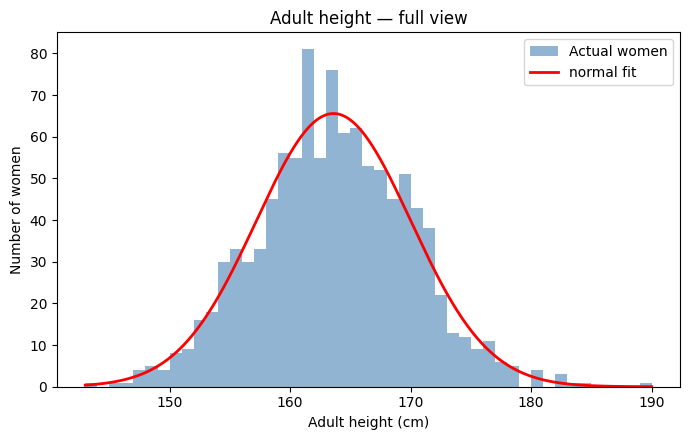

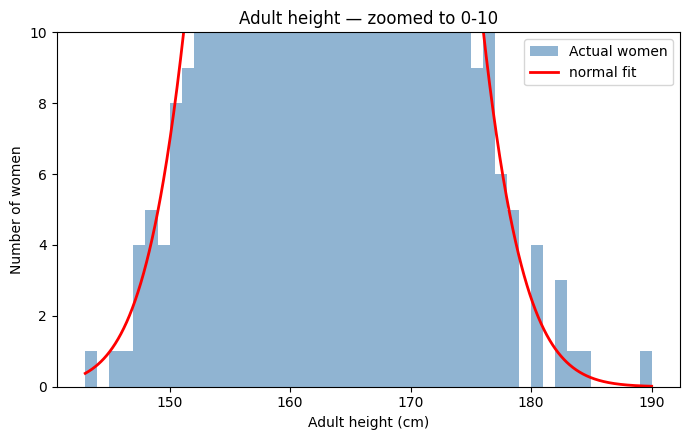

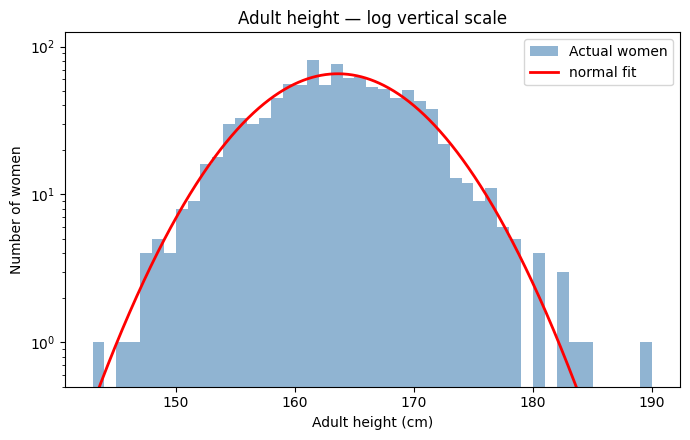

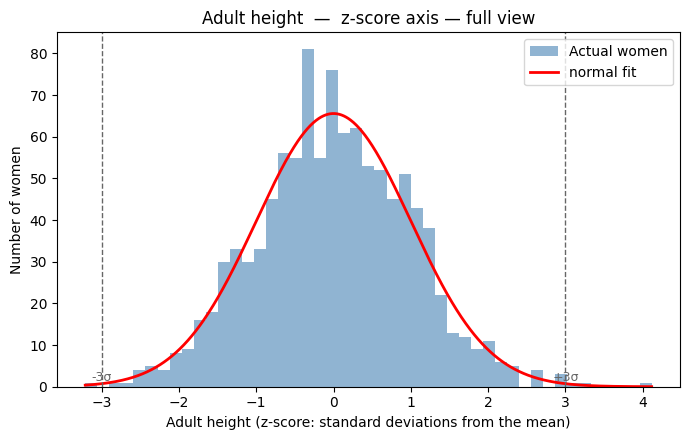

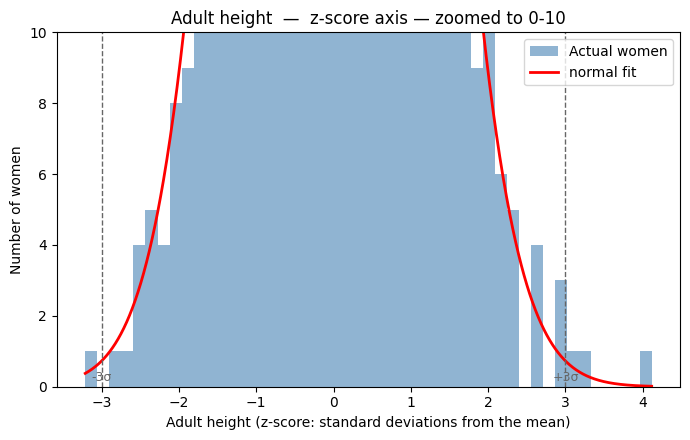

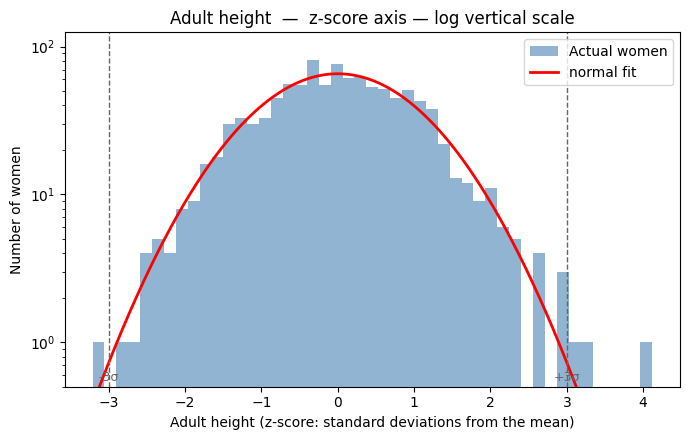

In [3]:
dt.analyze(height)

## What to notice

- The normal fit tracks the histogram closely everywhere, including on
  the log scale.
- Counts beyond 3 sigma are a handful, in line with the normal
  prediction; skewness and excess kurtosis are both near zero.
- Try widening the sample (drop the race/ethnicity filter, or mix in
  men) and watch the fit degrade -- mixing groups with different means
  is a common way to break normality.